In [75]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [77]:
df = pd.read_csv(r'C:\facultate\Facultate master 1\SEED\spotify 2023.csv', encoding='latin1')
df

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363,61,...,144,A,Major,60,24,39,57,0,8,3
949,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870,4,...,166,F#,Major,42,7,24,83,1,12,6
950,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683,2,...,92,C#,Major,80,81,67,4,0,8,6
951,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612,29,...,97,C#,Major,82,67,77,8,0,12,5


In [79]:
# 1. a) Numarul de randuri si coloane
#df.info()
num_rows, num_col = df.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_col}")
# 1. b) In cazul tabelelor multiple, cheile de legatura
# b) Nu se aplica la aceasta tabela

Number of rows: 953
Number of columns: 24


In [81]:
# 1. c) i) Pe coloane, numarul de inregistrari lipsa (proportia de date lipsa la nivel de coloana) 
empty_col = df.isnull().sum()
empty_col_percent = round(empty_col/len(df) * 100)

print("Missing values per column: ")
print(pd.DataFrame({"Missing values": empty_col, "Percentage": empty_col_percent}))

print("-----------------------------------------------------")

# 1. c) ii) Pe linii, numarul de inregistari cu cel putin o valoare lipsa (proporita de inregistrar incomplete)

rows_miss = df.isnull().any(axis=1).sum()
print(f"Rows with at least one missing value: {rows_miss}")

Missing values per column: 
                      Missing values  Percentage
track_name                         0         0.0
artist(s)_name                     0         0.0
artist_count                       0         0.0
released_year                      0         0.0
released_month                     0         0.0
released_day                       0         0.0
in_spotify_playlists               0         0.0
in_spotify_charts                  0         0.0
streams                            0         0.0
in_apple_playlists                 0         0.0
in_apple_charts                    0         0.0
in_deezer_playlists                0         0.0
in_deezer_charts                   0         0.0
in_shazam_charts                  50         5.0
bpm                                0         0.0
key                               95        10.0
mode                               0         0.0
danceability_%                     0         0.0
valence_%                          0     

In [83]:
df

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363,61,...,144,A,Major,60,24,39,57,0,8,3
949,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870,4,...,166,F#,Major,42,7,24,83,1,12,6
950,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683,2,...,92,C#,Major,80,81,67,4,0,8,6
951,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612,29,...,97,C#,Major,82,67,77,8,0,12,5


In [85]:
# 2. i) Tipurile de atribute

print("Types of each attribute: ")
df.dtypes

Types of each attribute: 


track_name              object
artist(s)_name          object
artist_count             int64
released_year            int64
released_month           int64
released_day             int64
in_spotify_playlists     int64
in_spotify_charts        int64
streams                 object
in_apple_playlists       int64
in_apple_charts          int64
in_deezer_playlists     object
in_deezer_charts         int64
in_shazam_charts        object
bpm                      int64
key                     object
mode                    object
danceability_%           int64
valence_%                int64
energy_%                 int64
acousticness_%           int64
instrumentalness_%       int64
liveness_%               int64
speechiness_%            int64
dtype: object

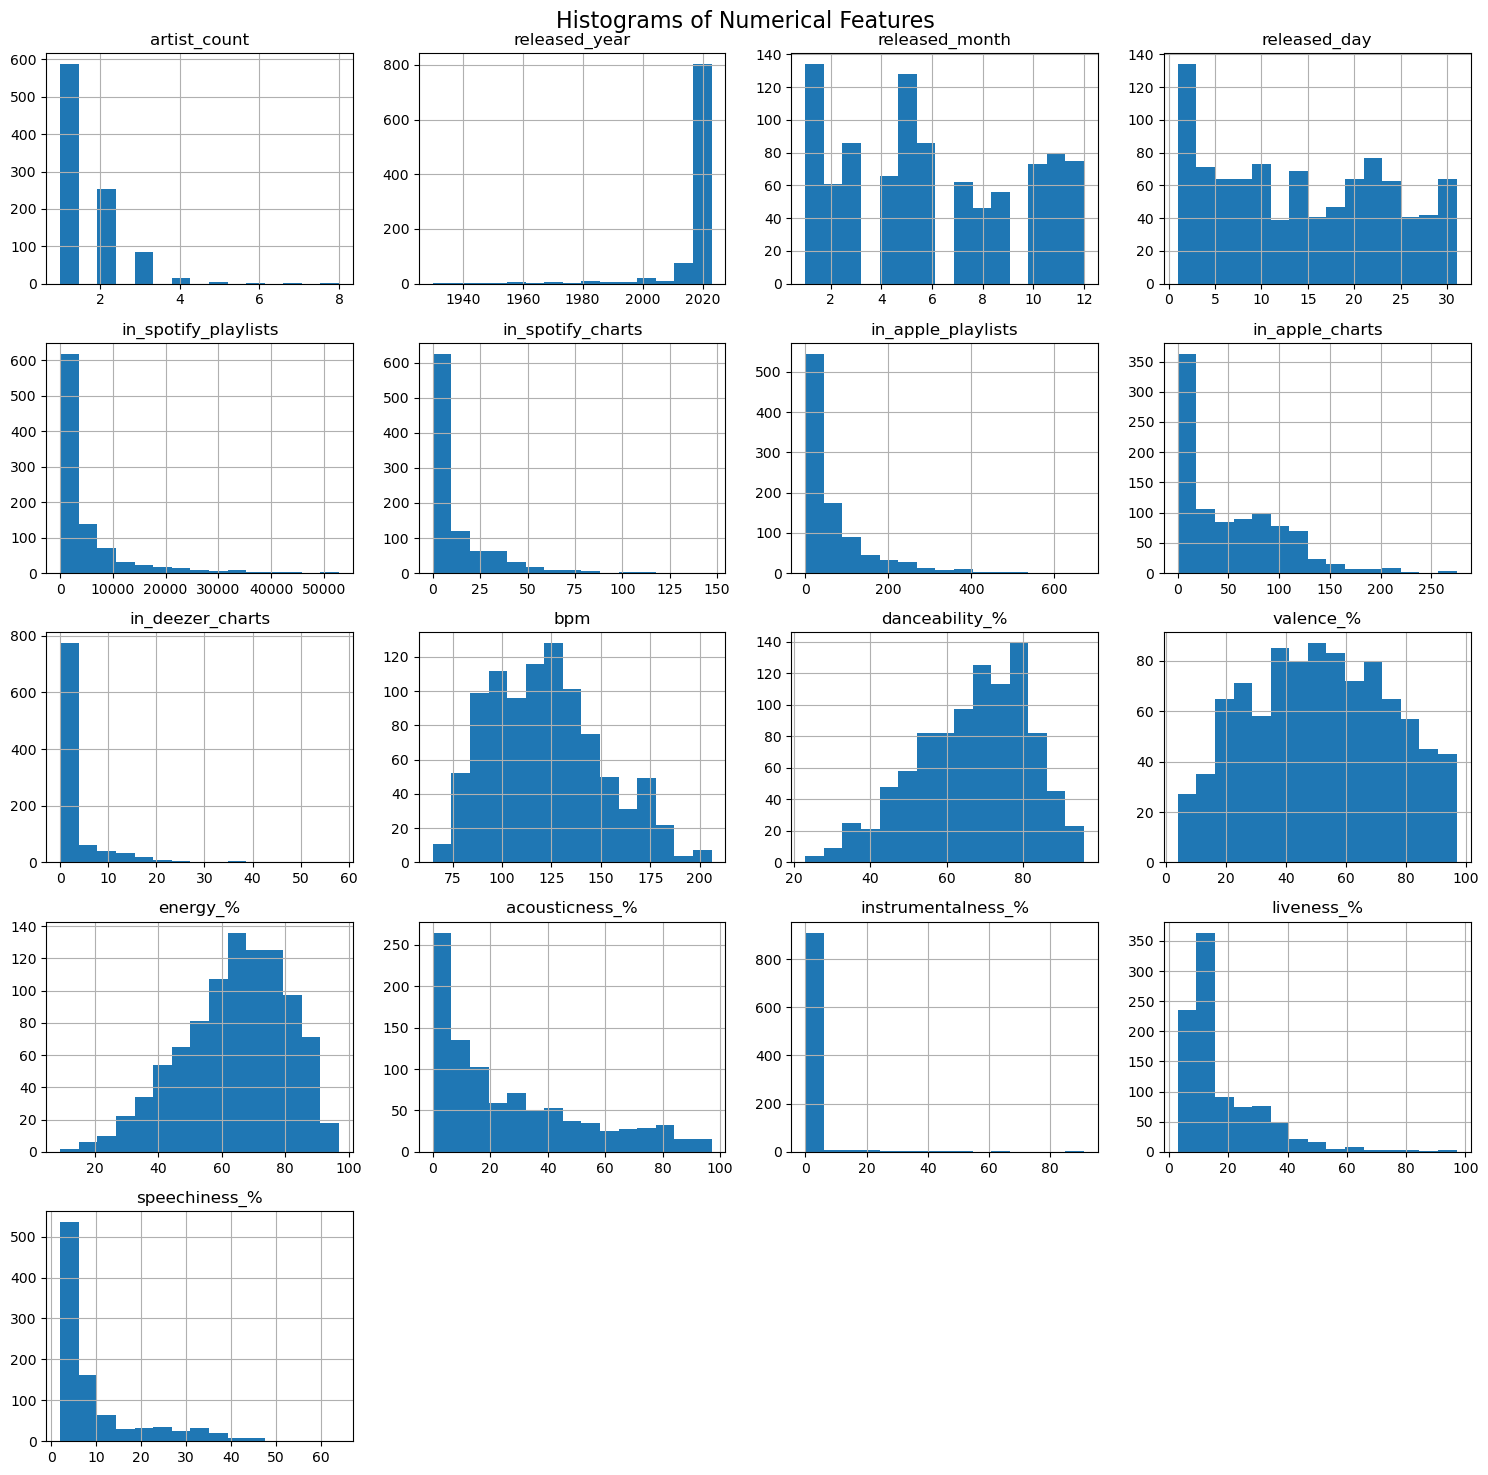

In [87]:
# 2. ii) Distributia valorilor - reprezentari grafice
numeric_col = df.select_dtypes(include='int64').columns
num_column = len(numeric_col)
rows = math.ceil(num_column / 4)  

df[numeric_col].hist(bins=15, figsize=(15, rows * 3), layout=(rows, 4))  # Adjust height based on rows
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [88]:
# 2. iii) Statistici simple pentru fiecare coloana numerica
df.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,67.812172,51.908709,2.666317,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,86.441493,50.630241,6.035599,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,13.000000,7.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,34.000000,38.000000,0.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,88.000000,87.000000,2.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,672.000000,275.000000,58.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


In [89]:
# 2. iv) Analiza valori extreme - Daca exista la nivel de atribut: Outliers - valori extreme care 
      #  ar putea fi eliminate pentru o mai buna intelegere a problemei si a modelarii

Q1 = df[numeric_col].quantile(0.25)
Q3 = df[numeric_col].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numeric_col] < (Q1 - 1.5 * IQR)) | (df[numeric_col] > (Q3 + 1.5 * IQR))).sum()
print("Potential outliers per numerical feature:")
print(outliers)

Potential outliers per numerical feature:
artist_count             27
released_year           151
released_month            0
released_day              0
in_spotify_playlists    109
in_spotify_charts        78
in_apple_playlists       78
in_apple_charts           9
in_deezer_charts        143
bpm                       5
danceability_%            3
valence_%                 0
energy_%                  4
acousticness_%            0
instrumentalness_%       87
liveness_%               44
speechiness_%           136
dtype: int64


In [90]:
# 2. v) Analiza valori extreme - Daca exista la nivel de atribut: Outliers - valori extreme care 
      # ar putea fi eliminate pentru o mai buna intelegere a problemei si a modelarii
print("Columns with negative values (if any):")
print(df[(df['streams'].astype(str).str.isnumeric() == False) | (df['bpm'] < 0)])

Columns with negative values (if any):
                              track_name     artist(s)_name  artist_count  \
574  Love Grows (Where My Rosemary Goes)  Edison Lighthouse             1   

     released_year  released_month  released_day  in_spotify_playlists  \
574           1970               1             1                  2877   

     in_spotify_charts                                            streams  \
574                  0  BPM110KeyAModeMajorDanceability53Valence75Ener...   

     in_apple_playlists  ...  bpm key   mode danceability_%  valence_%  \
574                  16  ...  110   A  Major             53         75   

    energy_% acousticness_%  instrumentalness_%  liveness_%  speechiness_%  
574       69              7                   0          17              3  

[1 rows x 24 columns]


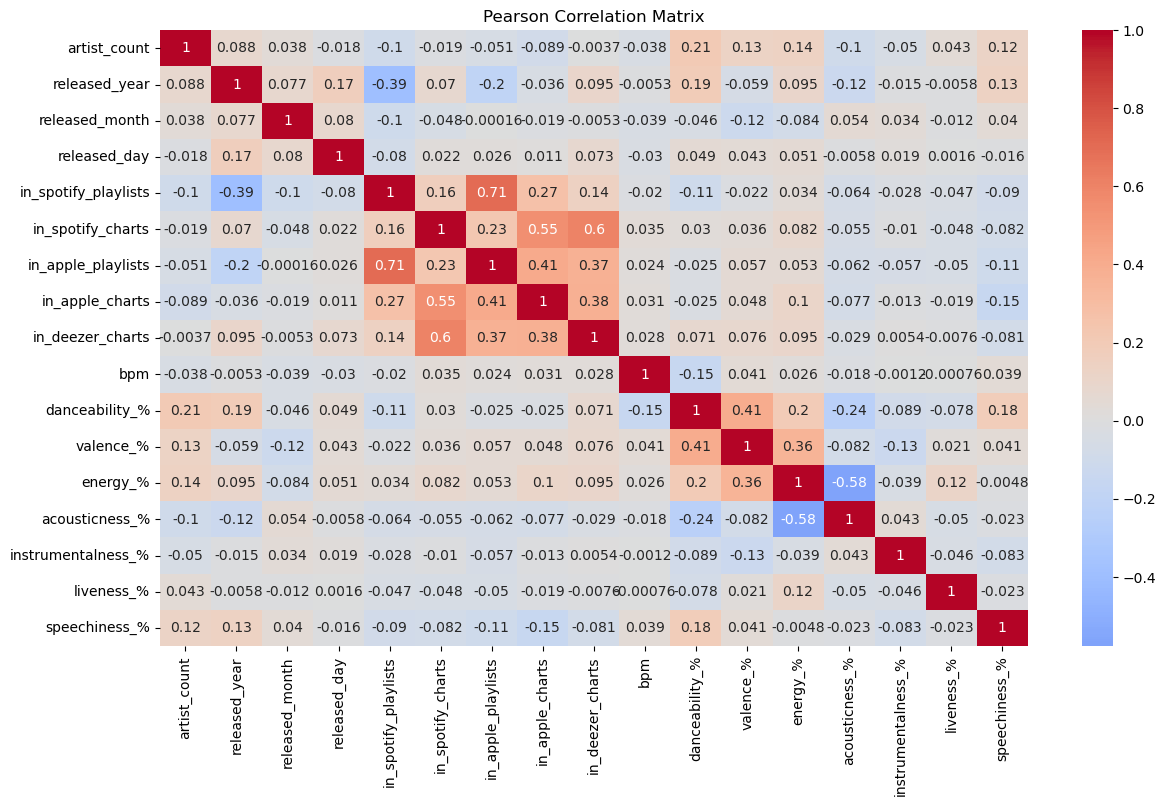

In [95]:
# 3. a) Matricea de corelatie Pearson
plt.figure(figsize=(14, 8))
sns.heatmap(df[numeric_col].corr(method='pearson'), annot=True, cmap='coolwarm', center=0)
plt.title('Pearson Correlation Matrix')
plt.show()

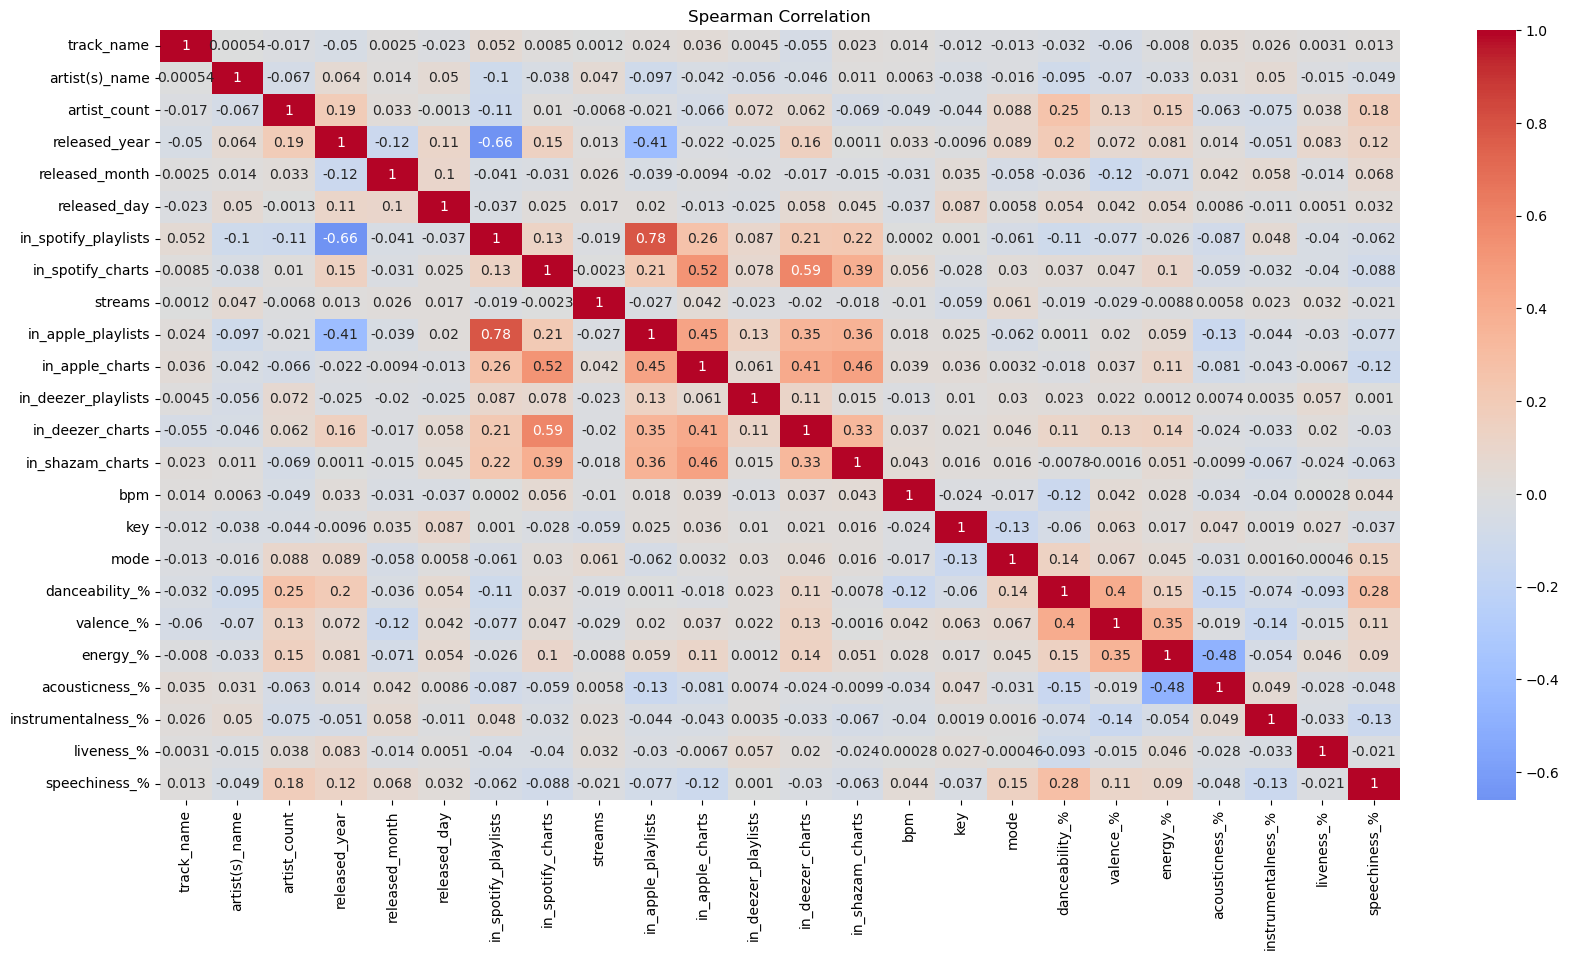

In [97]:
# 3. b) Matricea de corelatie Spearman
#    c) Reprezentarea grafica a matricei de corelatie
df_encoded = df.copy()
categorical_columns = df.select_dtypes(include=['object']).columns
label_encoders = {col: LabelEncoder() for col in categorical_columns}

for col in categorical_columns:
    df_encoded[col] = label_encoders[col].fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(20, 10))
sns.heatmap(df_encoded.corr(method='spearman'), annot=True, cmap='coolwarm', center=0)
plt.title('Spearman Correlation')
plt.show()

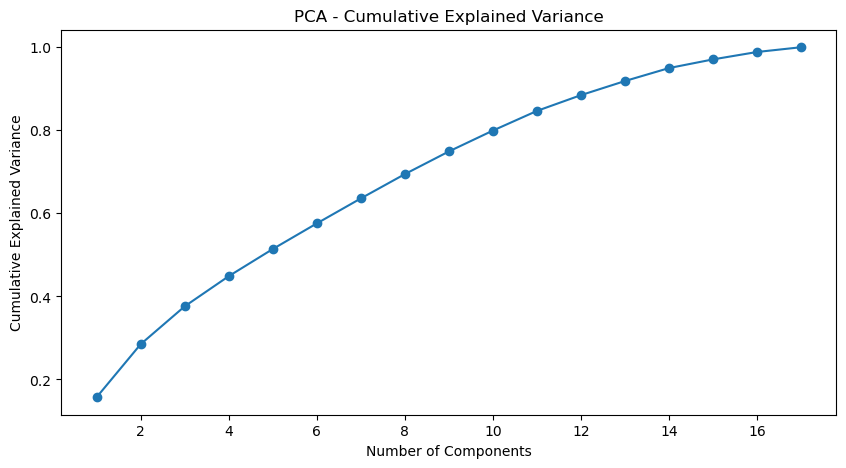

Number of components that explain at least 90% variance: 13


In [98]:
# 3) d) Analiza componentelor principale i)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_col].dropna()) 

pca = PCA()
pca_components = pca.fit_transform(scaled_data)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.show()

#print(pca.components_)

# 3) d) ii)
explained_variance = pca.explained_variance_ratio_.cumsum()
n_components_90 = (explained_variance >= 0.9).argmax() + 1
print(f"Number of components that explain at least 90% variance: {n_components_90}")

    

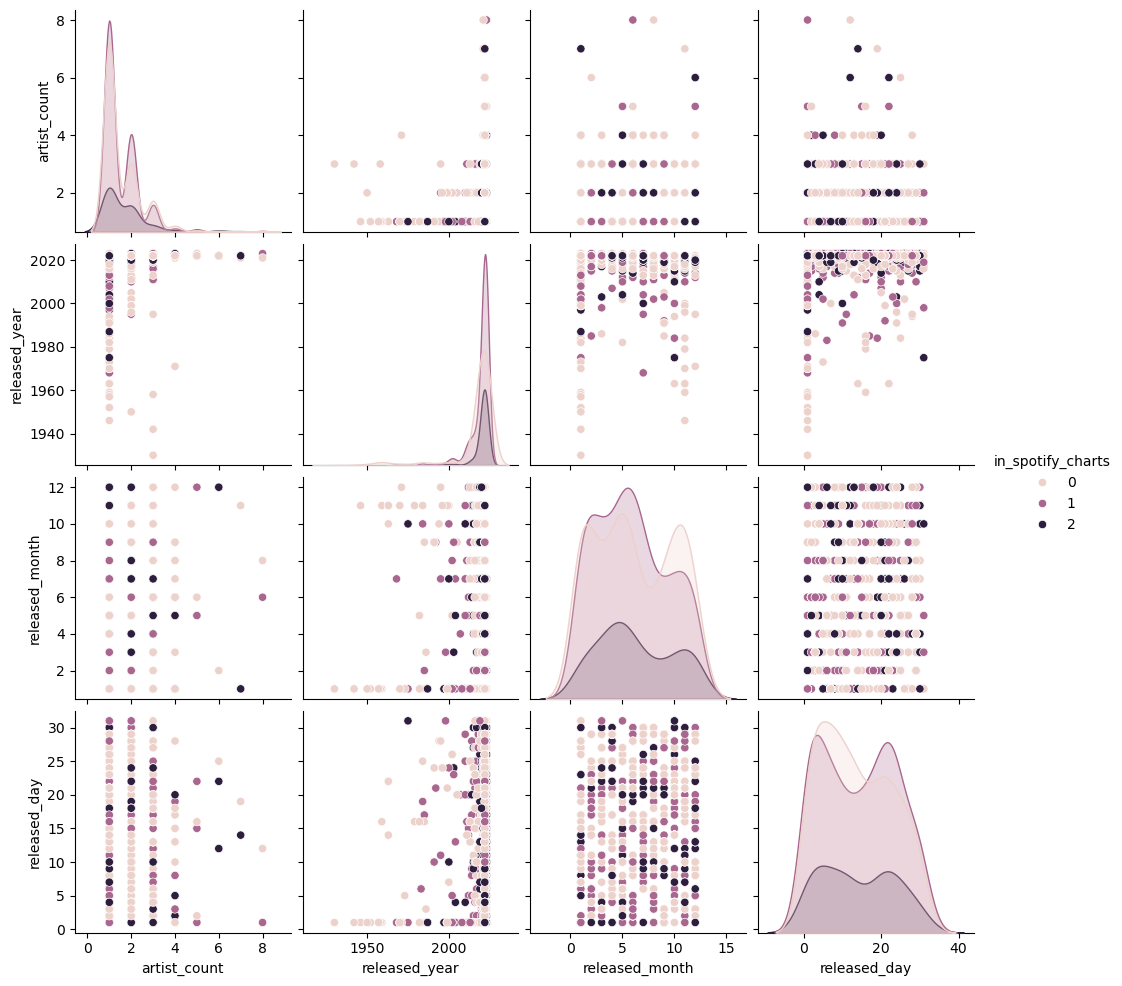

in_spotify_charts
1    407
0    405
2    141
Name: count, dtype: int64


In [99]:
# 4. a) Distributia atributelor pe clase (in_sporitfy_charts)
df['in_spotify_charts'] = df['in_spotify_charts'].apply(lambda x: 0 if x == 0 else (1 if x > 5 else 2))

sns.pairplot(df, hue='in_spotify_charts', vars=numeric_col[:4])
plt.show()
print(df['in_spotify_charts'].value_counts())


In [103]:
#II) Modelare clasificator

#1. Preprocesarea datelor

import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Selectam doar datele numerice si se inlocuiesc valorile nule cu mediana din fiecare coloana
df = df.select_dtypes(include=[np.number])  
df.fillna(df.median(), inplace=True)

X = df.drop('in_spotify_charts', axis=1)  
y = df['in_spotify_charts']  

# Scalarea datelor folosind MinMaxScaler
minmaxsclr = MinMaxScaler()
X_scaled = minmaxsclr.fit_transform(X)

# Impartirea setului de date (antrenament: 70%, test: 30%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, shuffle=True, random_state=40)

In [105]:
# 2. Definirea modelului si parametrilor pentru GridSearchCV
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": svm.SVC(),
    "Random Forest": RandomForestClassifier()
}

param_grids = {
    "Logistic Regression": {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "liblinear"]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_features": ["sqrt", "log2"],
        "max_depth": [None, 10, 20]
    }
}


In [107]:
# 3. Antrenarea modelelor cu GridSearchCV
best_models = {}
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5)
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    
    y_pred = best_model.predict(X_test)
    print(f"{model_name} Accuracy:", accuracy_score(y_test, y_pred))
    
    print(classification_report(y_test, y_pred, zero_division=1))



Training Logistic Regression...
Logistic Regression Accuracy: 0.6328671328671329
              precision    recall  f1-score   support

           0       0.60      0.82      0.69       122
           1       0.69      0.65      0.67       122
           2       0.67      0.05      0.09        42

    accuracy                           0.63       286
   macro avg       0.65      0.50      0.48       286
weighted avg       0.64      0.63      0.59       286


Training SVM...
SVM Accuracy: 0.6433566433566433
              precision    recall  f1-score   support

           0       0.60      0.82      0.69       122
           1       0.70      0.69      0.69       122
           2       1.00      0.00      0.00        42

    accuracy                           0.64       286
   macro avg       0.77      0.50      0.46       286
weighted avg       0.70      0.64      0.59       286


Training Random Forest...
Random Forest Accuracy: 0.6818181818181818
              precision    recall  f

In [109]:
# 4. Compararea rezultatelor modelelor
results = {
    'Model': list(best_models.keys()),
    'Accuracy': [
        accuracy_score(y_test, best_models[model_name].predict(X_test)) for model_name in best_models
    ]
}

df_results = pd.DataFrame(results)
print("\nModel Comparison:\n", df_results)


Model Comparison:
                  Model  Accuracy
0  Logistic Regression  0.632867
1                  SVM  0.643357
2        Random Forest  0.681818


In [45]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   artist_count          953 non-null    int64
 1   released_year         953 non-null    int64
 2   released_month        953 non-null    int64
 3   released_day          953 non-null    int64
 4   in_spotify_playlists  953 non-null    int64
 5   in_spotify_charts     953 non-null    int64
 6   in_apple_playlists    953 non-null    int64
 7   in_apple_charts       953 non-null    int64
 8   in_deezer_charts      953 non-null    int64
 9   bpm                   953 non-null    int64
 10  danceability_%        953 non-null    int64
 11  valence_%             953 non-null    int64
 12  energy_%              953 non-null    int64
 13  acousticness_%        953 non-null    int64
 14  instrumentalness_%    953 non-null    int64
 15  liveness_%            953 non-null    int64
 16  speechin

(953, 17)

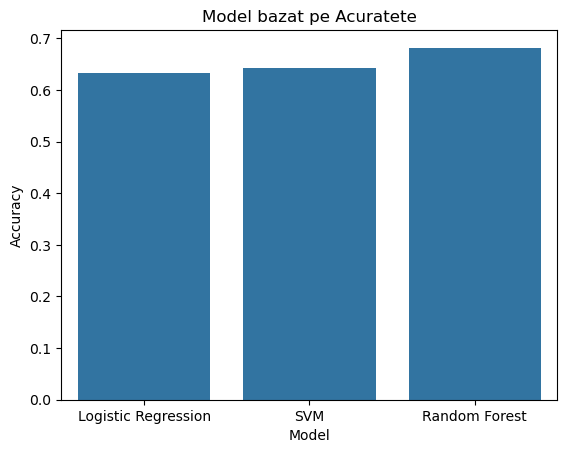

In [112]:
sns.barplot(x='Model', y='Accuracy', data=df_results)
plt.title("Model bazat pe Acuratete")
plt.show()

In [114]:
df.to_excel(r'C:\facultate\Facultate master 1\SEED\spotify.xlsx', index=False)

# II) Modelare clasificator
## a. Care este problema pe care o modelati- > care este variabila raspuns

a. Scopul este de a prezice daca o melodie apare in clasamentele Spotify (in_spotify_charts) 
- **0** Nu este prezenta in topuri
- **1** Este prezenta in top-uri, dar nu in top 5
- **2** Daca se afla in top 5

---

## b. Atribute numerice:
b. Atributele numerice din setul de date sunt analizate (ex de a.: streams, bpm) și distribuite prin histograme. (17 coloane numerice -> df.info())

--- 
## c. Alte atribute si codificarea lor:
c. Atributele categorice au fost indepartate pentru partea aceasta (artist(s)_name, track_name, steams, in_shazam_charts, key, mode)

--- 
## d. Atribute derivate: (daca aveti)
d. Nu atribute derivate, dar procesul de scalare poate fi considerat o transformare.

--- 
## e. Numar de inregistrari 
e. Reies din df.shape -> 953 randuri si 17 coloane

--- 
## Pentru fiecare model utilizat precizati:

--- 
## a. ce parametrii ati optimizat prin incercari (gridsearch), ce inseamna ei
a. Pentru Logistic Regression: "C" - controleaza regularizarea, "solver" - algoritm folosit pentru optimizare<br>
   Pentru SVM: "C" - Regularizarea modelului, "kernel" - Functia pentru separarea datelor<br>
   Pentru Random Forest: "n_estimators" - Numarul de arbori din padure, "max_features" - Numarul de caracteristici considerate la fiecare split, max_depth - Adancimea maxima a arborilor

--- 
## b. Precizati modul de antrenare: cum ati impartit datele, daca ati facut validare incrucisata si cum ati facut validarea incrucisata, daca ati folosit esantionare stratificata;
b. Acelasi mod de antrenare a fost utilizat pentru toate 3: validare incrucisata.

--- 
## c. Precizati metrica cu care ati cautat modelul/parametrii optimi.
c. 
- Logistic Regression: Acuratete;<br>
- SVM: Acuratete;<br>
- Random Forest: Acuratete;<br><br>

--- 
## d. Precizati rezultatul antrenarii: cel mai bun model, rezultat de prognoza pe date nefolosite in antrenament
- Logistic Regresiion:  Accuracy: 63.29%.<br>
Precision, Recall și F1-Score:<br>
Clasa 0: Precision 0.60, Recall 0.82, F1-Score 0.69.<br>
Clasa 1: Precision 0.69, Recall 0.65, F1-Score 0.67.<br>
Clasa 2: Precision 0.67, Recall 0.05, F1-Score 0.09<br><br>

- SVM: Accuracy: 64.34%.<br>
Precision, Recall și F1-Score:<br>
Clasa 0: Precision 0.60, Recall 0.82, F1-Score 0.69.<br>
Clasa 1: Precision 0.70, Recall 0.69, F1-Score 0.69.<br>
Clasa 2: Precision 1.00, Recall 0.00, F1-Score 0.00.<br><br>

- Random Forest: Accuracy: 68.18%.<br>
Precision, Recall și F1-Score:<br>
Clasa 0: Precision 0.68, Recall 0.82, F1-Score 0.74.<br>
Clasa 1: Precision 0.41, Recall 0.75, F1-Score 0.73.<br>
Clasa 2: Precision 0.38, Recall 0.07, F1-Score 0.12.<br><br>

Rezultatele testelor finale sunt rezumate astfel:<br>
- Logistic Regression: 63.29% acuratete.<br>
- SVM: 64.34% acuratete.<br>
- Random Forest: 68.18% acuratete

--- 
### Concluzie: 
Random Forest a obtinut cea mai mare acuratete si cele mai bune scoruri agregate pentru clasele 0 și 1, insa clasa 2 ramane problematica datorita dezechilibrului din date. Random Forest este modelul recomandat.in date. Random Forest este modelul recomandat.